# Trabalho Computacional — Equações Diferenciais I

## Decaimento radioativo da cadeia de massa 135


e compara os métodos de **Euler** e **Runge–Kutta de quarta ordem (RK4)** com a solução analítica.


## 1. Modelo matemático

O sistema de cinco equações diferenciais é

\[
\begin{aligned}
\frac{dN_1}{dt} &= -\lambda_1N_1,\\
\frac{dN_2}{dt} &= \lambda_1N_1-\lambda_2N_2,\\
\frac{dN_3}{dt} &= \lambda_2N_2-\lambda_3N_3,\\
\frac{dN_4}{dt} &= \lambda_3N_3-\lambda_4N_4,\\
\frac{dN_5}{dt} &= \lambda_4N_4.
\end{aligned}
\]

As condições iniciais em \(t=0\) são

\[
(N_1,N_2,N_3,N_4,N_5)=(1{,}0\times10^{24},\,0,\,0,\,0,\,0).
\]


In [1]:
# Bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 2. Parâmetros do problema

As constantes de decaimento são calculadas por
\(\lambda=\ln(2)/T_{1/2}\), com todos os tempos expressos em segundos.


In [2]:
# Tempos de meia-vida, em segundos, conforme o PDF
TEMPOS_MEIA_VIDA_S = np.array([102.0, 19.0, 23_652.0, 32_904.0])

# Constantes de decaimento (s^-1)
LAMBDA = np.log(2.0) / TEMPOS_MEIA_VIDA_S

# Condições iniciais e limites de tempo
N1_INICIAL = 1.0e24
Y_INICIAL = np.array([N1_INICIAL, 0.0, 0.0, 0.0, 0.0])
T_INICIAL = 0.0
T_FINAL = 600.0

# Passos exigidos no enunciado
PASSOS_EULER = [1.0, 5.0, 10.0]
PASSOS_RK4 = [2.0, 5.0, 10.0]

# Instantes em que o desvio relativo percentual será apresentado
TEMPOS_ERRO = np.array([0.0, 150.0, 300.0, 450.0, 600.0])

print("Constantes de decaimento:")
for nome, meia_vida, taxa in zip(
    ["Sb-135", "Te-135", "I-135", "Xe-135"],
    TEMPOS_MEIA_VIDA_S,
    LAMBDA,
):
    print(f"  {nome:6s}: lambda = {taxa:.6e} s^-1 (T1/2 = {meia_vida:g} s)")


Constantes de decaimento:
  Sb-135: lambda = 6.795561e-03 s^-1 (T1/2 = 102 s)
  Te-135: lambda = 3.648143e-02 s^-1 (T1/2 = 19 s)
  I-135 : lambda = 2.930607e-05 s^-1 (T1/2 = 23652 s)
  Xe-135: lambda = 2.106574e-05 s^-1 (T1/2 = 32904 s)


## 3. Implementação do sistema de equações diferenciais

A função abaixo recebe o vetor completo
\(\mathbf N=(N_1,N_2,N_3,N_4,N_5)\) e retorna suas cinco derivadas.


In [3]:
def sistema_radioativo(t, N, lambdas):
    """Retorna dN/dt para a cadeia de decaimento de massa 135."""
    lambda1, lambda2, lambda3, lambda4 = lambdas
    N1, N2, N3, N4, N5 = N

    # N5 não aparece diretamente porque é a espécie estável.
    return np.array(
        [
            -lambda1 * N1,
            lambda1 * N1 - lambda2 * N2,
            lambda2 * N2 - lambda3 * N3,
            lambda3 * N3 - lambda4 * N4,
            lambda4 * N4,
        ],
        dtype=float,
    )


## 4. Métodos numéricos

### Euler para sistemas

A fórmula vetorial utilizada é

\[
\mathbf N_{k+1}=\mathbf N_k+h\,\mathbf F(t_k,\mathbf N_k).
\]

### Runge–Kutta de quarta ordem (RK4)

O método utiliza quatro avaliações por passo:

\[
\begin{aligned}
\mathbf k_1 &= \mathbf F(t_k,\mathbf N_k),\\
\mathbf k_2 &= \mathbf F(t_k+h/2,\mathbf N_k+h\mathbf k_1/2),\\
\mathbf k_3 &= \mathbf F(t_k+h/2,\mathbf N_k+h\mathbf k_2/2),\\
\mathbf k_4 &= \mathbf F(t_k+h,\mathbf N_k+h\mathbf k_3),\\
\mathbf N_{k+1} &= \mathbf N_k+\frac{h}{6}
(\mathbf k_1+2\mathbf k_2+2\mathbf k_3+\mathbf k_4).
\end{aligned}


In [4]:
def euler_sistema(h, t_inicial, N_inicial, lambdas, n_passos):
    """Resolve o sistema pelo método de Euler com passo constante h."""
    tempos = np.empty(n_passos + 1, dtype=float)
    solucoes = np.empty((n_passos + 1, len(N_inicial)), dtype=float)

    tempos[0] = t_inicial
    solucoes[0] = N_inicial

    for k in range(n_passos):
        t = tempos[k]
        N = solucoes[k]
        solucoes[k + 1] = N + h * sistema_radioativo(t, N, lambdas)
        tempos[k + 1] = t + h

    return tempos, solucoes


In [5]:
def rk4_sistema(h, t_inicial, N_inicial, lambdas, n_passos):
    """Resolve o sistema pelo método clássico de Runge–Kutta de 4ª ordem."""
    tempos = np.empty(n_passos + 1, dtype=float)
    solucoes = np.empty((n_passos + 1, len(N_inicial)), dtype=float)

    tempos[0] = t_inicial
    solucoes[0] = N_inicial

    for k in range(n_passos):
        t = tempos[k]
        N = solucoes[k]

        k1 = sistema_radioativo(t, N, lambdas)
        k2 = sistema_radioativo(
            t + 0.5 * h, N + 0.5 * h * k1, lambdas
        )
        k3 = sistema_radioativo(
            t + 0.5 * h, N + 0.5 * h * k2, lambdas
        )
        k4 = sistema_radioativo(
            t + h, N + h * k3, lambdas
        )

        solucoes[k + 1] = N + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        tempos[k + 1] = t + h

    return tempos, solucoes


## 5. Solução analítica

Pela fórmula de Bateman, para \(k=1,2,3,4\),

\[
N_k(t)=N_1(0)
\left(\prod_{j=1}^{k-1}\lambda_j\right)
\sum_{i=1}^{k}
\frac{e^{-\lambda_i t}}
{\displaystyle\prod_{\substack{j=1\\j\ne i}}^{k}(\lambda_j-\lambda_i)}.
\]

Como o Cs-135 é estável e não há perda de núcleos da cadeia,

\[
N_5(t)=N_1(0)-N_1(t)-N_2(t)-N_3(t)-N_4(t).
\]

Essas expressões são implementadas a seguir.


In [6]:
def solucao_analitica(tempos):
    """Calcula N1(t), ..., N5(t) pela fórmula de Bateman e conservação."""
    tempos = np.asarray(tempos, dtype=float)
    solucao = np.zeros((len(tempos), 5), dtype=float)

    # N1, N2, N3 e N4 pela fórmula de Bateman.
    for quantidade in range(1, 5):
        produto_das_taxas = np.prod(LAMBDA[: quantidade - 1])

        for indice_taxa in range(quantidade):
            outras_taxas = np.delete(LAMBDA[:quantidade], indice_taxa)
            denominador = np.prod(outras_taxas - LAMBDA[indice_taxa])
            solucao[:, quantidade - 1] += (
                N1_INICIAL
                * produto_das_taxas
                * np.exp(-LAMBDA[indice_taxa] * tempos)
                / denominador
            )

    # N5 é a quantidade restante da cadeia.
    solucao[:, 4] = N1_INICIAL - np.sum(solucao[:, :4], axis=1)

    # Em t=0, o resultado é a definição das condições iniciais;
    # isso também elimina possíveis resíduos de arredondamento.
    mascara_t0 = np.isclose(tempos, T_INICIAL, rtol=0.0, atol=1e-12)
    solucao[mascara_t0, :] = Y_INICIAL

    return solucao


# Malha usada somente para desenhar as curvas analíticas.
TEMPO_ANALITICO = np.linspace(T_INICIAL, T_FINAL, 1201)
SOLUCAO_ANALITICA = solucao_analitica(TEMPO_ANALITICO)


## 6. Execução das simulações

Serão executadas exatamente as seis combinações solicitadas:

- Euler: \(h=1,0\), \(5,0\) e \(10,0\) s;
- RK4: \(h=2,0\), \(5,0\) e \(10,0\) s.


In [7]:
CONFIGURACOES = [
    ("Euler", 1.0, euler_sistema),
    ("Euler", 5.0, euler_sistema),
    ("Euler", 10.0, euler_sistema),
    ("RK4", 2.0, rk4_sistema),
    ("RK4", 5.0, rk4_sistema),
    ("RK4", 10.0, rk4_sistema),
]

RESULTADOS = {}

for metodo, h, solver in CONFIGURACOES:
    n_passos = int(round((T_FINAL - T_INICIAL) / h))

    # Evita que o número de passos não corresponda exatamente a 600 s.
    if not np.isclose(T_INICIAL + n_passos * h, T_FINAL):
        raise ValueError(f"O passo h={h} s não divide o intervalo de 0 a 600 s.")

    tempos, solucoes = solver(
        h=h,
        t_inicial=T_INICIAL,
        N_inicial=Y_INICIAL,
        lambdas=LAMBDA,
        n_passos=n_passos,
    )
    RESULTADOS[(metodo, h)] = {"tempo": tempos, "N": solucoes}

    print(
        f"{metodo:5s} | h = {h:4.1f} s | "
        f"n = {n_passos:3d} | t_final = {tempos[-1]:.1f} s"
    )


Euler | h =  1.0 s | n = 600 | t_final = 600.0 s
Euler | h =  5.0 s | n = 120 | t_final = 600.0 s
Euler | h = 10.0 s | n =  60 | t_final = 600.0 s
RK4   | h =  2.0 s | n = 300 | t_final = 600.0 s
RK4   | h =  5.0 s | n = 120 | t_final = 600.0 s
RK4   | h = 10.0 s | n =  60 | t_final = 600.0 s


## 7. Desvio relativo percentual

Será utilizado o desvio relativo percentual absoluto:

\[
\text{erro}(\%)=
\frac{\left|N_{\mathrm{numérica}}(t)-N_{\mathrm{analítica}}(t)\right|}
{\left|N_{\mathrm{analítica}}(t)\right|}\times100.
\]

Em \(t=0\), \(N_2=N_3=N_4=N_5=0\); por isso, o desvio dessas espécies não pode ser calculado por divisão. Nessas posições, a tabela apresenta **—** em vez de um valor indefinido.


In [8]:
def desvio_relativo_percentual(numerica, analitica):
    """Calcula |numérica - analítica| / |analítica| * 100 em %."""
    analitica = np.asarray(analitica, dtype=float)
    desvio = np.full(analitica.shape, np.nan, dtype=float)

    mascara = np.abs(analitica) > 0.0
    desvio[mascara] = (
        np.abs(np.asarray(numerica)[mascara] - analitica[mascara])
        / np.abs(analitica[mascara])
        * 100.0
    )
    return desvio


NOMES_NUCLEIDEOS = [
    "N1 — Sb-135",
    "N2 — Te-135",
    "N3 — I-135",
    "N4 — Xe-135",
    "N5 — Cs-135 (estável)",
]

registros = []

for (metodo, h), resultado in RESULTADOS.items():
    indices = np.rint((TEMPOS_ERRO - T_INICIAL) / h).astype(int)

    for indice_especie, nome in enumerate(NOMES_NUCLEIDEOS):
        valores_numericos = resultado["N"][indices, indice_especie]
        valores_analiticos = solucao_analitica(TEMPOS_ERRO)[
            :, indice_especie
        ]
        desvios = desvio_relativo_percentual(
            valores_numericos, valores_analiticos
        )

        for indice_tempo, (tempo, desvio) in enumerate(zip(TEMPOS_ERRO, desvios)):
            registros.append(
                {
                    "Método": metodo,
                    "Passo h (s)": h,
                    "Substância": nome,
                    "Instante (s)": int(tempo),
                    "Desvio relativo (%)": desvio,
                }
            )

ERROS = pd.DataFrame.from_records(registros)


In [9]:
# Uma tabela para cada substância, como solicitado no PDF.
for nome in NOMES_NUCLEIDEOS:
    tabela = ERROS.loc[ERROS["Substância"] == nome].pivot(
        index=["Método", "Passo h (s)"],
        columns="Instante (s)",
        values="Desvio relativo (%)",
    )

    ordem = pd.MultiIndex.from_tuples(
        [(metodo, h) for metodo, h, _ in CONFIGURACOES],
        names=["Método", "Passo h (s)"],
    )
    tabela = tabela.reindex(ordem)
    tabela_formatada = tabela.copy()

    for tempo in TEMPOS_ERRO:
        coluna = int(tempo)
        tabela_formatada[coluna] = tabela[coluna].map(
            lambda valor: "—" if pd.isna(valor) else f"{valor:.6e}%"
        )

    tabela_formatada.columns = [f"t = {int(t)} s" for t in TEMPOS_ERRO]
    print(f"\nDesvios relativos percentuais — {nome}")
    display(tabela_formatada)



Desvios relativos percentuais — N1 — Sb-135


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                           
Euler  1.0          0.000000e+00%  3.473199e-01%  6.934335e-01%  1.038345e+00%  1.382058e+00%
       5.0          0.000000e+00%  1.756384e+00%  3.481919e+00%  5.177147e+00%  6.842600e+00%
       10.0         0.000000e+00%  3.563786e+00%  7.000567e+00%  1.031487e+01%  1.351105e+01%
RK4    2.0          0.000000e+00%  2.931406e-08%  5.862809e-08%  8.794220e-08%  1.172562e-07%
       5.0          0.000000e+00%  1.164712e-06%  2.329423e-06%  3.494135e-06%  4.658847e-06%
       10.0         0.000000e+00%  1.917124e-05%  3.834249e-05%  5.751374e-05%  7.668499e-05%


Desvios relativos percentuais — N2 — Te-135


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                    
Euler  1.0               —  2.368266e-01%  6.910178e-01%  1.038305e+00%  1.382058e+00%
       5.0               —  1.265499e+00%  3.473171e+00%  5.177026e+00%  6.842599e+00%
       10.0              —  2.737506e+00%  6.988893e+00%  1.031473e+01%  1.351105e+01%
RK4    2.0               —  1.588585e-06%  2.138101e-08%  8.729163e-08%  1.172461e-07%
       5.0               —  6.809146e-05%  7.349704e-07%  3.466287e-06%  4.658414e-06%
       10.0              —  1.272743e-03%  8.583899e-06%  5.699372e-05%  7.667692e-05%


Desvios relativos percentuais — N3 — I-135


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                    
Euler  1.0               —  2.611958e-01%  1.332473e-01%  6.444456e-02%  2.988743e-02%
       5.0               —  1.330826e+00%  6.691918e-01%  3.213187e-01%  1.479720e-01%
       10.0              —  2.725241e+00%  1.345655e+00%  6.401907e-01%  2.921747e-01%
RK4    2.0               —  2.141921e-07%  9.944919e-09%  5.452409e-09%  2.537944e-09%
       5.0               —  9.240738e-06%  3.910454e-07%  2.166121e-07%  1.008360e-07%
       10.0              —  1.744193e-04%  6.311226e-06%  3.564742e-06%  1.659765e-06%


Desvios relativos percentuais — N4 — Xe-135


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                    
Euler  1.0               —  5.472113e-01%  1.059081e-01%  2.758558e-02%  6.569420e-03%
       5.0               —  2.771503e+00%  5.319174e-01%  1.374827e-01%  3.235157e-02%
       10.0              —  5.634232e+00%  1.069740e+00%  2.737619e-01%  6.342846e-02%
RK4    2.0               —  4.187969e-08%  9.184835e-09%  2.676005e-09%  8.591506e-10%
       5.0               —  1.939063e-06%  3.640686e-07%  1.062081e-07%  3.398608e-08%
       10.0              —  4.031140e-05%  5.973110e-06%  1.748085e-06%  5.593535e-07%


Desvios relativos percentuais — N5 — Cs-135 (estável)


t = 0 s      t = 150 s      t = 300 s      t = 450 s      t = 600 s
Método Passo h (s)                                                                    
Euler  1.0               —  2.188129e+00%  8.031558e-01%  4.387206e-01%  2.861649e-01%
       5.0               —  1.084056e+01%  4.013104e+00%  2.194301e+00%  1.431327e+00%
       10.0              —  2.142292e+01%  8.019559e+00%  4.390425e+00%  2.863931e+00%
RK4    2.0               —  1.054531e-07%  1.570839e-08%  3.019333e-09%  1.067873e-09%
       5.0               —  3.699848e-06%  5.233525e-07%  9.314898e-08%  2.162344e-08%
       10.0              —  5.585501e-05%  8.569197e-06%  1.522526e-06%  3.476189e-07%

## 8. Gráficos comparativos

Para cada nuclídeo, o mesmo gráfico mostra a solução analítica e as seis soluções numéricas especificadas no enunciado.


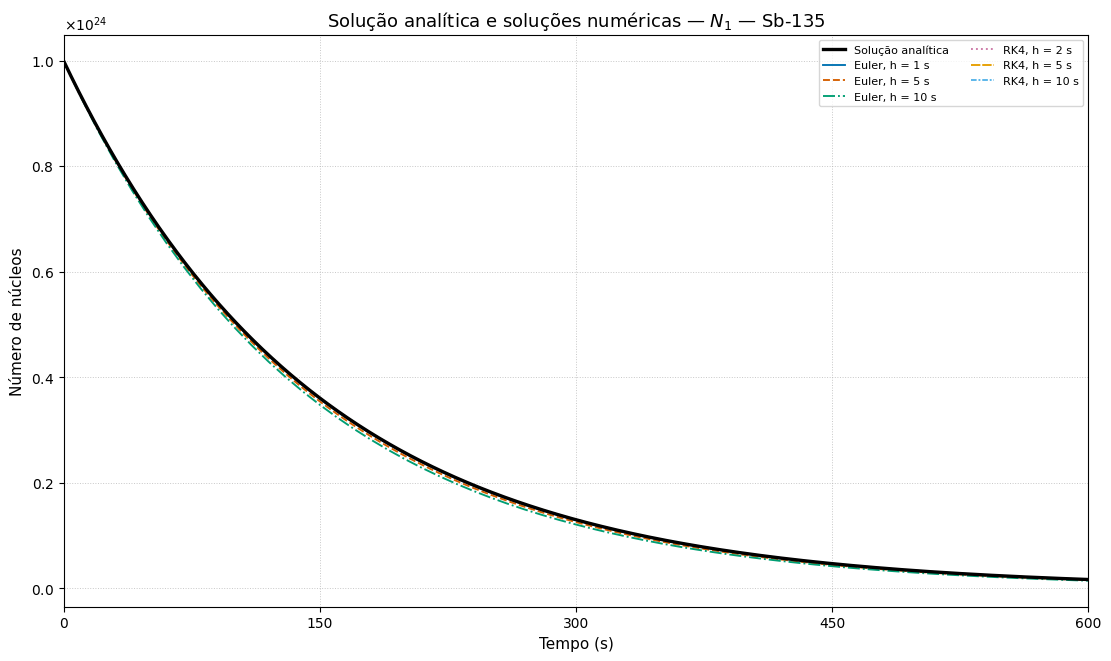

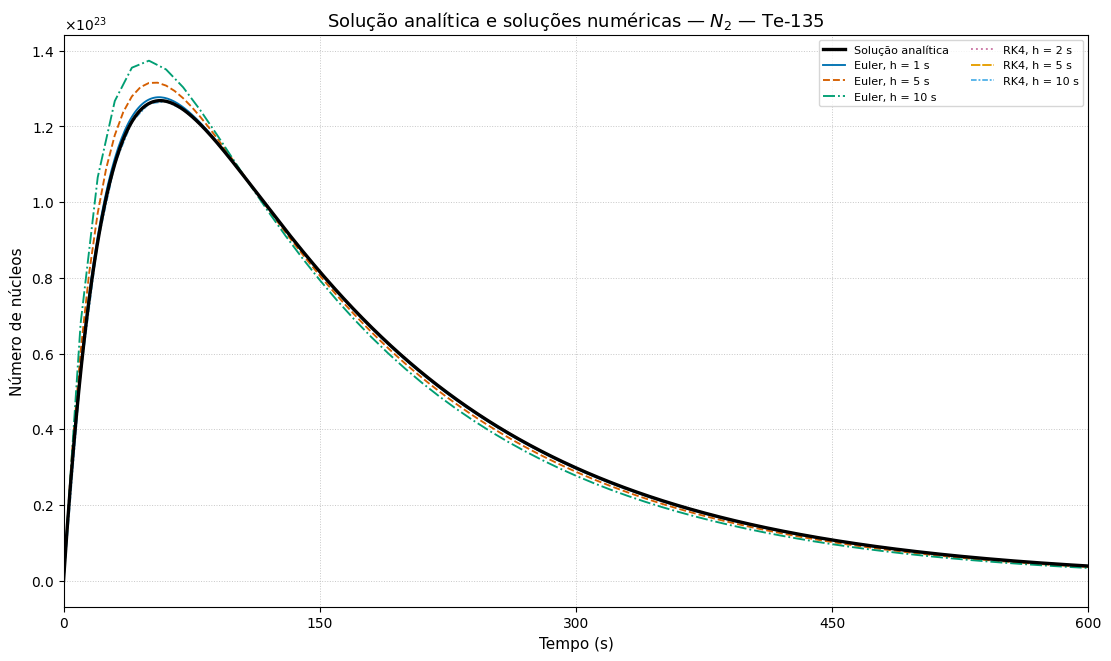

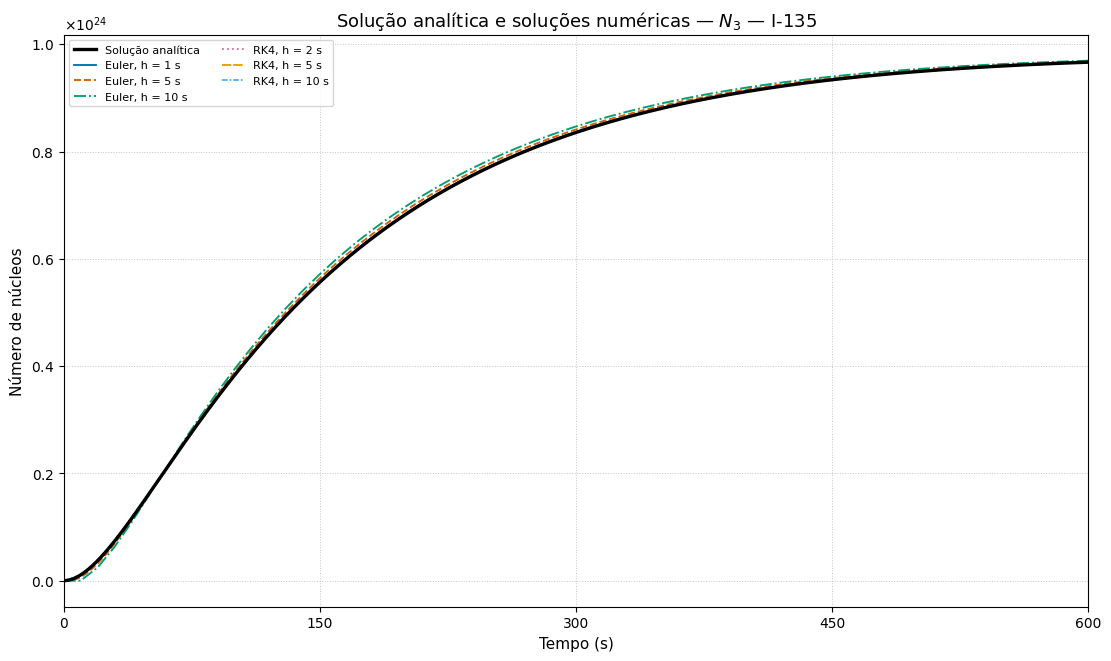

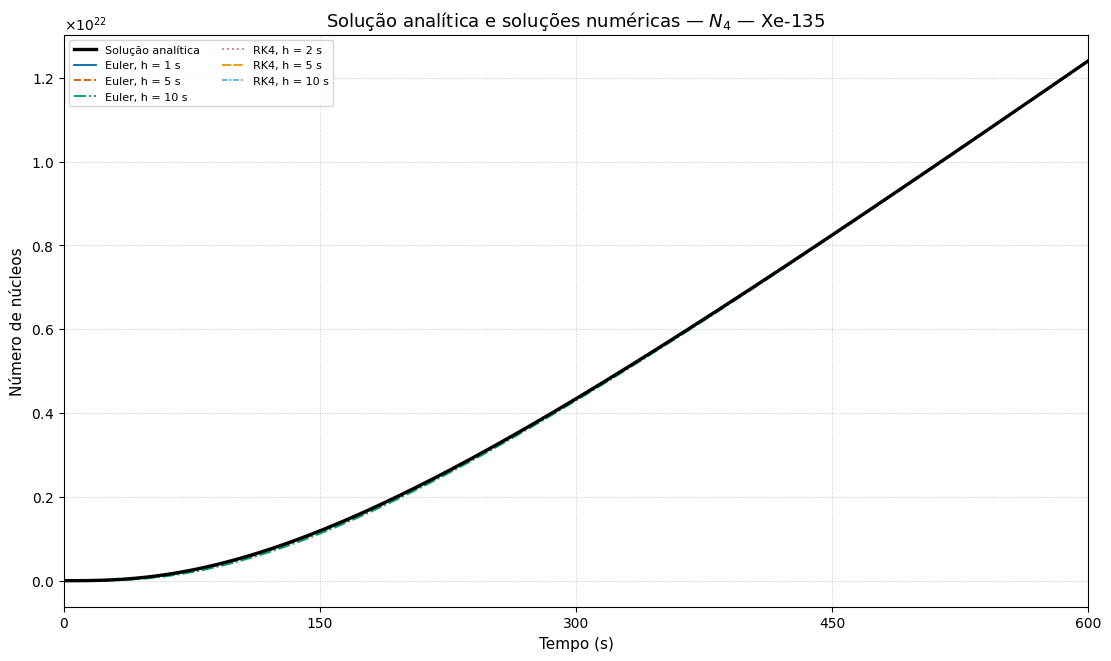

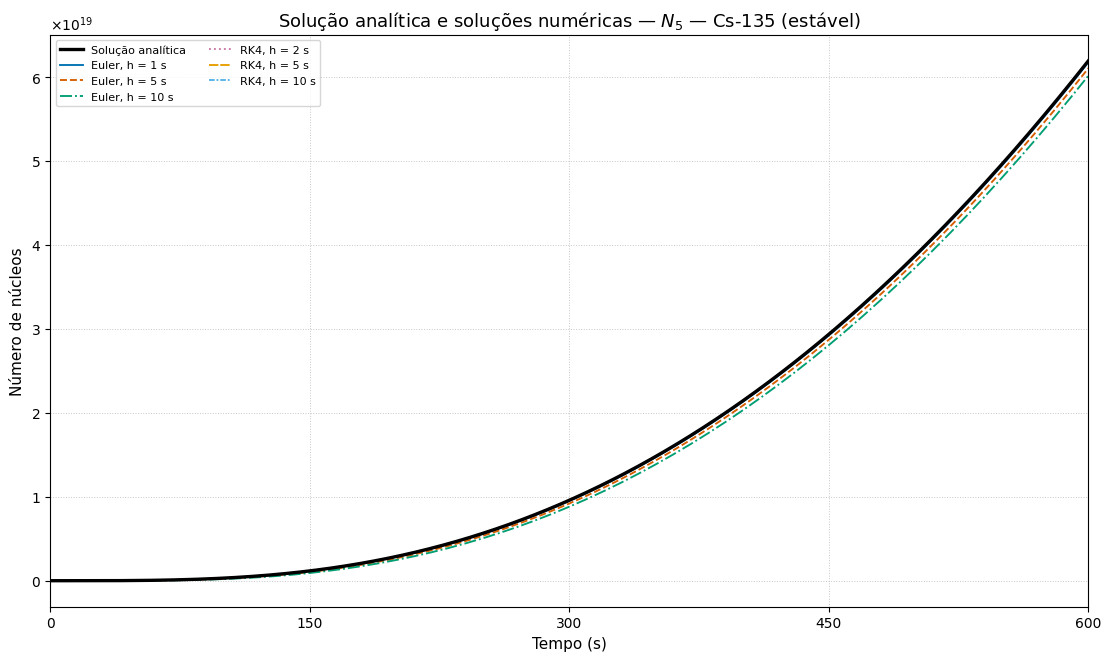

In [10]:
CORES = [
    "#0072B2",  # azul
    "#D55E00",  # laranja
    "#009E73",  # verde
    "#CC79A7",  # rosa
    "#E69F00",  # amarelo
    "#56B4E9",  # azul-claro
]
ESTILOS = ["-", "--", "-.", ":", (0, (5, 1)), (0, (3, 1, 1, 1))]
TITULOS_GRAFICOS = [
    r"$N_1$ — Sb-135",
    r"$N_2$ — Te-135",
    r"$N_3$ — I-135",
    r"$N_4$ — Xe-135",
    r"$N_5$ — Cs-135 (estável)",
]

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 8,
    }
)

for indice_especie, titulo in enumerate(TITULOS_GRAFICOS):
    fig, ax = plt.subplots(figsize=(11, 6.5), constrained_layout=True)

    ax.plot(
        TEMPO_ANALITICO,
        SOLUCAO_ANALITICA[:, indice_especie],
        color="black",
        linewidth=2.4,
        label="Solução analítica",
        zorder=5,
    )

    for indice, (metodo, h, _) in enumerate(CONFIGURACOES):
        resultado = RESULTADOS[(metodo, h)]
        ax.plot(
            resultado["tempo"],
            resultado["N"][:, indice_especie],
            color=CORES[indice],
            linestyle=ESTILOS[indice],
            linewidth=1.35,
            label=f"{metodo}, h = {h:g} s",
        )

    ax.set_title(f"Solução analítica e soluções numéricas — {titulo}")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Número de núcleos")
    ax.set_xlim(T_INICIAL, T_FINAL)
    ax.set_xticks(TEMPOS_ERRO)
    ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)
    ax.legend(loc="best", ncol=2, frameon=True)

    plt.show()
    plt.close(fig)


## 9. Discussão dos resultados

A tabela de resumo abaixo calcula a média do desvio relativo percentual em todos os valores válidos da tabela pedida. Essa média é usada apenas para responder objetivamente qual combinação apresentou o melhor desempenho.


In [11]:
RESUMO_DESVIO = (
    ERROS.dropna(subset=["Desvio relativo (%)"])
    .groupby(["Método", "Passo h (s)"], as_index=False)
    .agg(**{"Desvio relativo médio (%)": ("Desvio relativo (%)", "mean")})
)

RESUMO_EXIBICAO = RESUMO_DESVIO.sort_values(
    "Desvio relativo médio (%)"
).copy()
RESUMO_EXIBICAO["Desvio relativo médio (%)"] = RESUMO_EXIBICAO[
    "Desvio relativo médio (%)"
].map(lambda valor: f"{valor:.6e}%")
display(RESUMO_EXIBICAO)

melhor = RESUMO_DESVIO.loc[RESUMO_DESVIO["Desvio relativo médio (%)"].idxmin()]
print(
    f"Melhor desempenho: {melhor['Método']} com h = {melhor['Passo h (s)']:g} s "
    f"(desvio relativo médio = {melhor['Desvio relativo médio (%)']:.6e}%)."
)

for metodo in ["Euler", "RK4"]:
    parte = RESUMO_DESVIO.loc[RESUMO_DESVIO["Método"] == metodo]
    menor_passo = parte.loc[parte["Passo h (s)"].idxmin()]
    maior_passo = parte.loc[parte["Passo h (s)"].idxmax()]
    print(
        f"Em {metodo}, o passo {menor_passo['Passo h (s)']:g} s apresentou "
        f"erro médio {menor_passo['Desvio relativo médio (%)']:.6e}%, "
        f"enquanto o passo {maior_passo['Passo h (s)']:g} s apresentou "
        f"{maior_passo['Desvio relativo médio (%)']:.6e}%."
    )


,Método,Passo h (s),Desvio relativo médio (%)
3,RK4,2.0,1.199819e-07%
4,RK4,5.0,5.015656e-06%
5,RK4,10.0,9.083579e-05%
0,Euler,1.0,5.572182e-01%
1,Euler,5.0,2.782771e+00%
2,Euler,10.0,5.556368e+00%


Melhor desempenho: RK4 com h = 2 s (desvio relativo médio = 1.199819e-07%).
Em Euler, o passo 1 s apresentou erro médio 5.572182e-01%, enquanto o passo 10 s apresentou 5.556368e+00%.
Em RK4, o passo 2 s apresentou erro médio 1.199819e-07%, enquanto o passo 10 s apresentou 9.083579e-05%.


### Conclusões da comparação

- O **RK4** é método de quarta ordem e, nos passos estudados, obtém resultados muito mais próximos da solução analítica do que o Euler.
- O **Euler** é método de primeira ordem; por isso, seu erro cresce de forma mais evidente quando o passo aumenta.
- Para ambos os métodos, **diminuir \(h\)** aumenta o número de etapas, mas melhora a precisão. A escolha do passo deve considerar o equilíbrio entre precisão e custo computacional.
- Os gráficos e a tabela devem ser usados para registrar os valores específicos obtidos na execução deste notebook.
